# Instructions
- If code not running, add shortcut to "Capstone Project" folder to MyDrive and rerun all cells

In [ ]:
print('test')

test


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import gamma


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Capstone Project/data'))

['car_mpg.csv', 'generation_costs.xlsx', 'vehicles.csv', 'operations_emissions_by_fuel_and state.csv', 'egrid2023_data_rev1.xlsx', 'battery_emissions.xlsx', 'production_material_ratios.gsheet', 'emissions_by_vehicle_type.xlsx', 'Battery_material_emissions.xlsx', 'production_co2_per_kg.gsheet', 'Copy of production_co2_per_kg.gsheet', 'common_vehicles.csv', 'SelectedStateRankingsData.csv', 'weibull_parameters.gsheet', 'common_vehicles.gsheet', 'cost of electricity generation.gsheet', 'energyGenerationData.xlsx']


# New Section

In [ ]:
vehicles_df = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/vehicles.csv')
vehicles_df.head()

<ipython-input-5-c699cba493d7>:1: DtypeWarning: Columns (74,75,77) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles_df = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/vehicles.csv')


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [ ]:
common_vehicles_df = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/common_vehicles.csv')
common_vehicles_df.head()

,category,type,year,brand,model,city_mpg,highway_mpg,combined_mpg,weight_lbs
0,ICE,Sedan,2024,Toyota,Camry AWD LE/SE,25,34,29,3310
1,ICE,SUV,2024,Toyota,RAV4 AWD,27,33,29,3640
2,ICE,Truck,2024,Ford,F-150 4WD 5.0L,16,24,19,5122
3,PHEV,Sedan,2024,Toyota,Camry Hybrid LE,51,53,52,3480
4,PHEV,SUV,2024,Toyota,RAV4 Hybrid AWD,41,38,39,3775


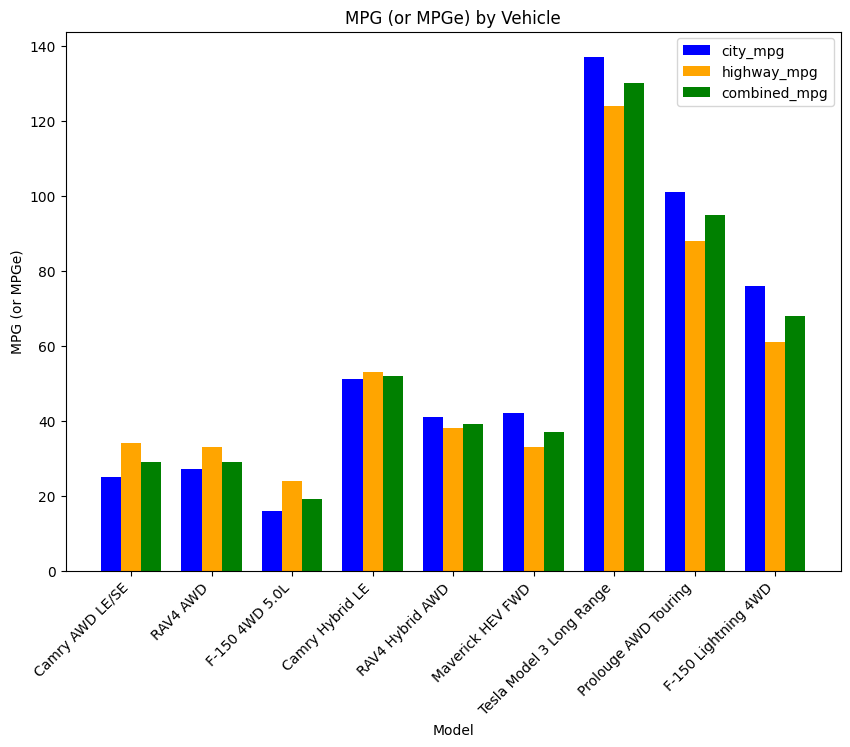

In [ ]:
# Set figure size
plt.figure(figsize=(10, 7))

# Set bar width and positions
bar_width = 0.25
x = np.arange(len(common_vehicles_df["model"]))  # X-axis positions

# Create bars for city, highway, and combined MPG
plt.bar(x - bar_width, common_vehicles_df["city_mpg"], width=bar_width, label="city_mpg", color="blue")
plt.bar(x, common_vehicles_df["highway_mpg"], width=bar_width, label="highway_mpg", color="orange")
plt.bar(x + bar_width, common_vehicles_df["combined_mpg"], width=bar_width, label="combined_mpg", color="green")

# Add labels and title
plt.xlabel("Model")
plt.ylabel("MPG (or MPGe)")
plt.title("MPG (or MPGe) by Vehicle")
plt.xticks(ticks=x, labels=common_vehicles_df["model"], rotation=45, ha="right")
# Add legend
plt.legend()

# Show the plot
plt.show()


In [ ]:

operations_emissions = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/operations_emissions_by_fuel_and state.csv')
operations_emissions.head()

<ipython-input-8-102dc4a8d24e>:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  operations_emissions = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/operations_emissions_by_fuel_and state.csv')


,year,parent_name,utility_name,utility_id_eia,utility_type_rmi,plant_id_eia,plant_name_eia,generator_id,state,city,...,owned_energy_source,technology_eia,technology_rmi,energy_source_code,fuel_type_category,net_generation,fuel_consumed,emissions_co2,emissions_nox,emissions_sox
0,2022,Tate & Lyle Ingredients Americas Inc,A E Staley Manufacturing Co,7,Industrial,10867.0,Decatur Cogen,GEN1,IL,Decatur,...,True,Natural Gas Steam Turbine,Gas,BIT,coal,0.000000,0.0,0.000000,0.000,0.0000
1,2022,Tate & Lyle Ingredients Americas Inc,A E Staley Manufacturing Co,7,Industrial,10867.0,Decatur Cogen,GEN1,IL,Decatur,...,True,Natural Gas Steam Turbine,Gas,NG,gas,0.283825,1241551.0,0.065766,0.000,0.0000
2,2022,Tate & Lyle Ingredients Americas Inc,AE Staley Manufacturing Co,8,Industrial,50903.0,Sagamore Plant Cogen,GEN1,IN,Lafayette,...,True,Natural Gas Steam Turbine,Gas,BIT,coal,0.000000,0.0,0.000000,0.000,0.0000
3,2022,Tate & Lyle Ingredients Americas Inc,AE Staley Manufacturing Co,8,Industrial,50903.0,Sagamore Plant Cogen,GEN1,IN,Lafayette,...,True,Natural Gas Steam Turbine,Gas,NG,gas,0.031878,747543.0,0.039598,0.000,0.0000
4,2022,Greenidge Generation Holdings LLC,GMM Holdings 1 LLC,25,Independent Power Producer,2527.0,Greenidge,4,NY,Dresden,...,True,Natural Gas Steam Turbine,Gas,BIT,coal,0.000000,0.0,0.000000,9.267,0.3566


In [ ]:
# Parameters for Weibull Function

eta_gasoline = 11.6  # Scale parameter for gasoline cars
beta_gasoline = 1.9  # Shape parameter for gasoline cars

eta_electric = 13.3
beta_electric = 2.1

eta_hybrid = 12.4
beta_hybrid = 2.0


In [ ]:
def weibull_pdf(x, eta, beta):
    """
    Probability Density Function (PDF) of the Weibull distribution.

    Parameters:
    x (float or array): Vehicle age.
    eta (float): Scale parameter.
    beta (float): Shape parameter.

    Returns:
    float or array: Probability density at age x.
    """
    return (beta / eta) * (x / eta) ** (beta - 1) * np.exp(-(x / eta) ** beta)

In [ ]:
def weibull_cdf(x, eta, beta):
    """
    Cumulative Distribution Function (CDF) of the Weibull distribution.

    Parameters:
    x (float or array): Vehicle age.
    eta (float): Scale parameter.
    beta (float): Shape parameter.

    Returns:
    float or array: Probability of a vehicle reaching end-of-life by age x.
    """
    return 1 - np.exp(-(x / eta) ** beta)


ages = np.linspace(0, 30)  # Vehicle ages from 0 to 30 years
#print("Ages", ages)
cdf_values = weibull_cdf(ages, eta_gasoline, beta_gasoline)

cdf_values

array([0.        , 0.00373144, 0.01385538, 0.02969536, 0.05073918,
       0.07648346, 0.10640786, 0.13997213, 0.17662078, 0.21579087,
       0.25692103, 0.29946064, 0.34287867, 0.38667172, 0.43037098,
       0.47354799, 0.51581904, 0.55684822, 0.59634913, 0.63408533,
       0.66986962, 0.70356226, 0.73506835, 0.76433447, 0.79134481,
       0.8161169 , 0.83869708, 0.85915603, 0.8775842 , 0.89408752,
       0.90878333, 0.92179664, 0.93325678, 0.94329442, 0.9520391 ,
       0.9596171 , 0.96614974, 0.97175209, 0.97653201, 0.98058955,
       0.98401654, 0.98689654, 0.98930487, 0.99130888, 0.99296832,
       0.99433576, 0.99545717, 0.99637242, 0.99711584, 0.99771684])

In [ ]:
spending_df = pd.read_csv('/content/drive/MyDrive/Capstone Project/data/SelectedStateRankingsData.csv')
spending_df.head()

,State,"Production, U.S. Share","Production, Rank","Consumption per Capita, Million Btu","Consumption per Capita, Rank","Expenditures per Capita, Dollars","Expenditures per Capita, Rank",Federal offshore production is not included in the Production Shares.
0,AK,1.4,13,987,1,13051,1,NaN
1,WY,6.1,4,853,4,11221,2,NaN
2,ND,4.2,8,861,3,10507,3,NaN
3,LA,4.9,6,925,2,9781,4,NaN
4,IA,0.8,19,445,7,6927,5,NaN


In [ ]:
def ICE(c1, E_X1, MPG, MPY, OilCoef):
    """
    Calculate the emissions for an Internal Combustion Engine (ICE) vehicle.

    Parameters:
    c1 (float): Constant related to production emissions.
    E_X1 (float): Expected vehicle lifetime in years.
    MPG (float): Miles per gallon fuel efficiency.
    MPY (float): Miles driven per year.
    OilCoef (float): Emissions coefficient per unit of fuel.

    Returns:
    float: Total emissions of an ICE vehicle.
    """
    return (c1 / E_X1) + (1 / MPG) * MPY * OilCoef


In [ ]:
def H(c2, E_X2, MPG, MPY, OilCoef):
    """
    Calculate the emissions for a Hybrid (H) vehicle.

    Parameters:
    c2 (float): Constant related to production emissions.
    E_X2 (float): Expected vehicle lifetime in years.
    MPG (float): Miles per gallon fuel efficiency.
    MPY (float): Miles driven per year.
    OilCoef (float): Emissions coefficient per unit of fuel.

    Returns:
    float: Total emissions of a hybrid vehicle.
    """
    return (c2 / E_X2) + (1 / MPG) * MPY * OilCoef

In [ ]:
def EV(c, E_X, EF, MPY, dR_dr):
    """
    Calculate the emissions for an Electric Vehicle (EV).

    Parameters:
    c (float): Constant related to production emissions.
    E_X (float): Expected vehicle lifetime in years.
    EF (float): Emissions factor related to electricity production.
    MPY (float): Miles driven per year.
    dR_dr (float): Factor accounting for the emissions rate per unit of energy used.

    Returns:
    float: Total emissions of an electric vehicle.
    """
    return (c / E_X) + (EF * MPY * dR_dr)


In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gamma

# Weibull expected lifetime function
def expected_lifetime(eta, beta):
    """
    Computes the expected lifetime of a vehicle using the Weibull distribution.

    Parameters:
    eta (float): Scale parameter
    beta (float): Shape parameter

    Returns:
    float: Expected lifetime in years
    """
    return eta * gamma(1 + 1/beta)

# Given Weibull parameters for vehicle types
weibull_params = {
    "ICE": (11.6, 1.9),
    "Hybrid": (12.4, 2.0),
    "EV": (13.3, 2.1)
}

# Expected lifetime for each vehicle type
lifetimes = {vehicle: expected_lifetime(*params) for vehicle, params in weibull_params.items()}

# Constants (assumed)
MPG = {"ICE": 25, "Hybrid": 50, "EV": None}  # Miles per gallon (EV uses electricity)
MPY = 13500  # Average miles driven per year
OilCoef = 19.6  # kg CO2 per gallon of gasoline
MPE = {"EV": 4.0}  # Miles per kWh
dR_dr = 0.4  # kg CO2 per kWh of electricity (grid-dependent)
manufacturing_emissions = {"ICE": 7500, "Hybrid": 8000, "EV": 12000}  # kg CO2 per vehicle

# Emissions functions
def lifetime_emissions(vehicle_type):
    """
    Computes lifetime emissions for a vehicle.

    Parameters:
    vehicle_type (str): "ICE", "Hybrid", or "EV"

    Returns:
    float: Total lifetime emissions (kg CO2)
    """
    E_X = lifetimes[vehicle_type]
    if vehicle_type in ["ICE", "Hybrid"]:
        return manufacturing_emissions[vehicle_type] + (MPY / MPG[vehicle_type]) * OilCoef * E_X
    elif vehicle_type == "EV":
        return manufacturing_emissions[vehicle_type] + (MPY / MPE["EV"]) * dR_dr * E_X

# Cost function (simplified present value model)
fuel_cost_per_gallon = 3.20
electricity_cost_per_kWh = 0.25

def lifetime_cost(vehicle_type):
    """
    Computes total lifetime cost of a vehicle, including fuel/electricity.

    Parameters:
    vehicle_type (str): "ICE", "Hybrid", or "EV"

    Returns:
    float: Total cost in dollars
    """
    E_X = lifetimes[vehicle_type]
    if vehicle_type in ["ICE", "Hybrid"]:
        return (MPY / MPG[vehicle_type]) * fuel_cost_per_gallon * E_X
    elif vehicle_type == "EV":
        return (MPY / MPE["EV"]) * electricity_cost_per_kWh * E_X

# Objective function for optimization (weighted sum of emissions and cost)
def objective(weights):
    """
    Computes a weighted sum of emissions and cost to optimize both factors.

    Parameters:
    weights (tuple): Weighting factors (w1, w2) for emissions and cost

    Returns:
    float: Weighted sum to minimize
    """
    w1, w2 = weights  # w1 = weight for emissions, w2 = weight for cost
    total = 0
    for vehicle in ["ICE", "Hybrid", "EV"]:
        emissions = lifetime_emissions(vehicle)
        cost = lifetime_cost(vehicle)
        total += w1 * emissions + w2 * cost
    return total

# Optimize by adjusting weights (finding best tradeoff)
result = minimize(objective, x0=(0.5, 0.5), bounds=[(0, 1), (0, 1)])

# Optimized weights for emissions vs. cost tradeoff
optimal_weights = result.x
print(f"Optimal weight for emissions: {optimal_weights[0]:.4f}")
print(f"Optimal weight for cost: {optimal_weights[1]:.4f}")

# Recalculate emissions and costs with optimal weights
optimized_values = {vehicle: (lifetime_emissions(vehicle), lifetime_cost(vehicle)) for vehicle in ["ICE", "Hybrid", "EV"]}

print("\nOptimized Emissions and Costs:")
for vehicle, values in optimized_values.items():
    print(f"{vehicle}: Emissions = {values[0]:,.2f} kg CO2, Cost = ${values[1]:,.2f}")
